# Project Summary / Resume Highlights

- Developed an end-to-end **Hospital Readmission Prediction** machine learning project using healthcare patient records to identify patients likely to be readmitted within 30 days.  
- Performed **data cleaning and preprocessing** by handling missing values, encoding categorical variables, and preparing structured features for model training.  
- Conducted **Exploratory Data Analysis (EDA)** to uncover trends in age groups, diagnoses, inpatient visits, medications, and readmission risk.  
- Created business-focused features such as patient visit frequency, medication count, and prior admissions to improve predictive performance.  
- Compared multiple classification algorithms including **Logistic Regression, Random Forest, and XGBoost**.  
- Applied **Cross Validation** and **Hyperparameter Tuning (GridSearchCV)** to improve model stability and optimize performance.  
- Evaluated models using **Accuracy, Precision, Recall, F1-score, and ROC-AUC**.  
- Identified top predictors of readmission using feature importance analysis.  
- Generated actionable insights to help hospitals reduce avoidable readmissions and improve patient care.  
- Demonstrated skills in **Python, Pandas, Scikit-learn, XGBoost, Data Visualization, and Predictive Modeling**.


Step 1 - Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
hospitalreadmission = pd.read_csv('c:/Users/Tanishq/Downloads/archive (24)/diabetic_data.csv')

Step 2 - Basic Data Understanding

In [2]:
hospitalreadmission.shape

(101766, 50)

In [3]:
hospitalreadmission.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [4]:
hospitalreadmission.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [5]:
hospitalreadmission.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [6]:
hospitalreadmission.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
# As the Number of missing values dominate in these columns so we to drop these columns as they can affect the performance of the model.
hospitalreadmission.drop(columns=['max_glu_serum','A1Cresult'],inplace=True,errors='ignore')

In [8]:
hospitalreadmission.nunique()

encounter_id                101766
patient_nbr                  71518
race                             6
gender                           3
age                             10
weight                          10
admission_type_id                8
discharge_disposition_id        26
admission_source_id             17
time_in_hospital                14
payer_code                      18
medical_specialty               73
num_lab_procedures             118
num_procedures                   7
num_medications                 75
number_outpatient               39
number_emergency                33
number_inpatient                21
diag_1                         717
diag_2                         749
diag_3                         790
number_diagnoses                16
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride                      4
acetohexamide                    2
glipizide           

In [9]:
hospitalreadmission.duplicated().sum()

0

Step 3 - Prepare Target Variable

In [10]:
hospitalreadmission['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [11]:
hospitalreadmission['Target']= hospitalreadmission['readmitted'].apply(lambda x:0 if x == 'NO' else 1)

In [12]:
hospitalreadmission['Target'].value_counts()

Target
0    54864
1    46902
Name: count, dtype: int64

In [13]:
hospitalreadmission.drop('readmitted', axis=1, inplace=True)

Step 4 - Exploratory Data Analysis

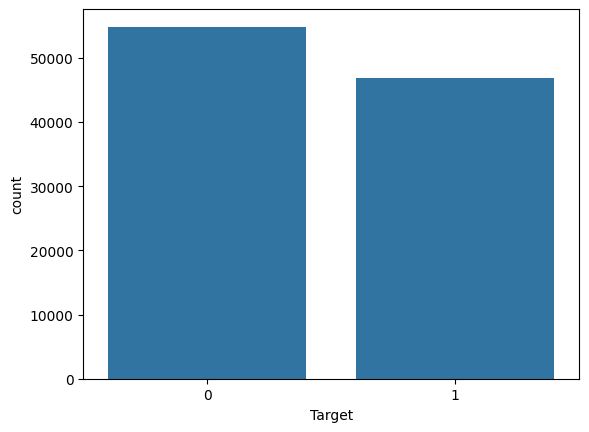

In [14]:
sns.countplot(x='Target', data=hospitalreadmission)
plt.show()

In [15]:
pd.crosstab(hospitalreadmission['age'], hospitalreadmission['Target'], normalize='index')*100

Target,0,1
age,,
[0-10),81.987578,18.012422
[10-20),61.794501,38.205499
[20-30),54.978877,45.021123
[30-40),57.324503,42.675497
[40-50),55.549819,44.450181
[50-60),56.044274,43.955726
[60-70),53.747276,46.252724
[70-80),51.879699,48.120301
[80-90),51.729953,48.270047


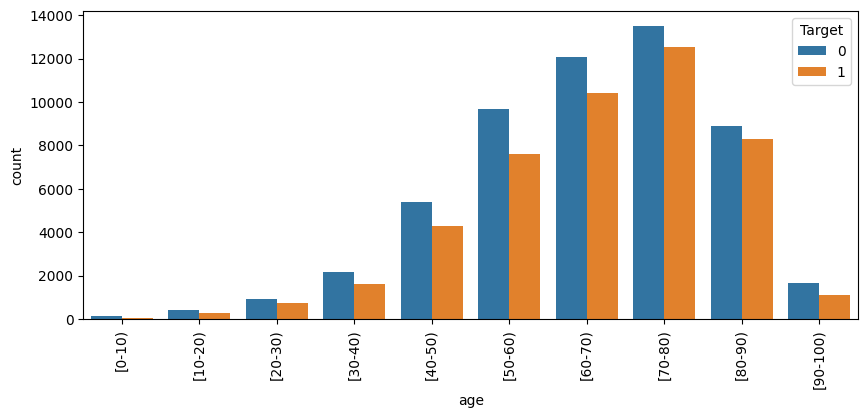

In [16]:
plt.figure(figsize=(10,4))
sns.countplot(x='age',hue='Target',data=hospitalreadmission)
plt.xticks(rotation=90)
plt.show()

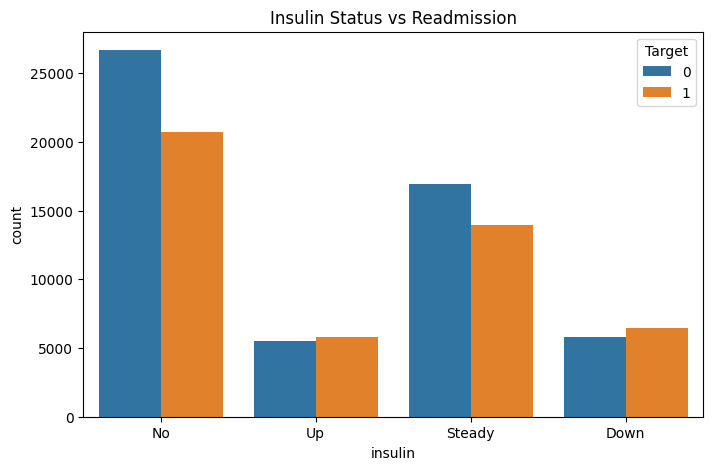

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='insulin', hue='Target', data=hospitalreadmission)
plt.title("Insulin Status vs Readmission")
plt.show()

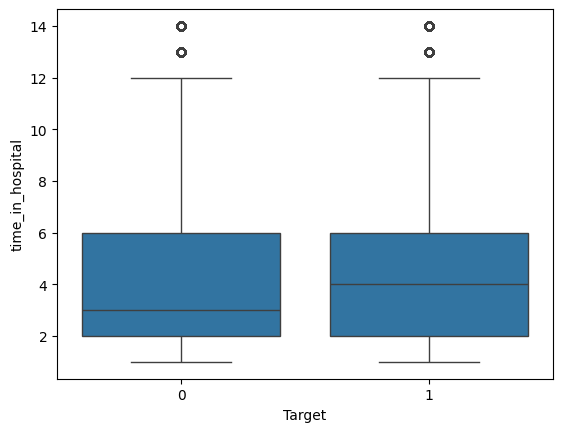

In [18]:
sns.boxplot(x='Target', y='time_in_hospital', data=hospitalreadmission)
plt.show()

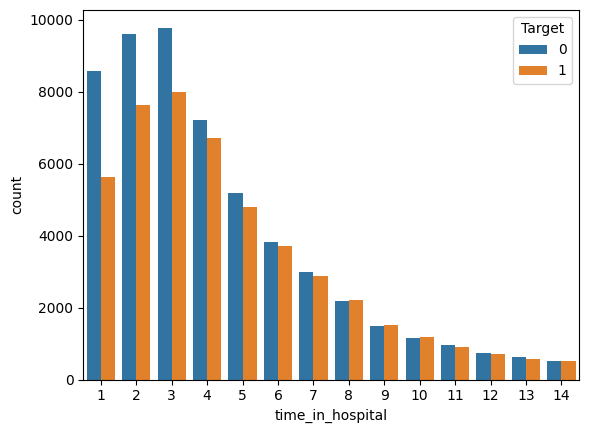

In [19]:
sns.countplot(x='time_in_hospital',hue='Target', data=hospitalreadmission)
plt.show()

In [20]:
hospitalreadmission['time_in_hospital'].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

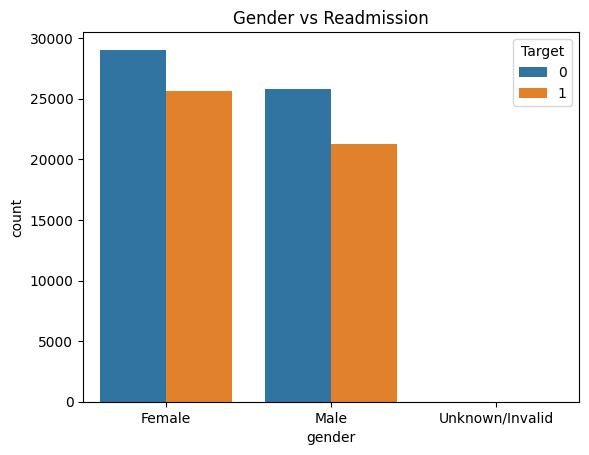

In [21]:
sns.countplot(x='gender', hue='Target', data=hospitalreadmission)
plt.title("Gender vs Readmission")
plt.show()

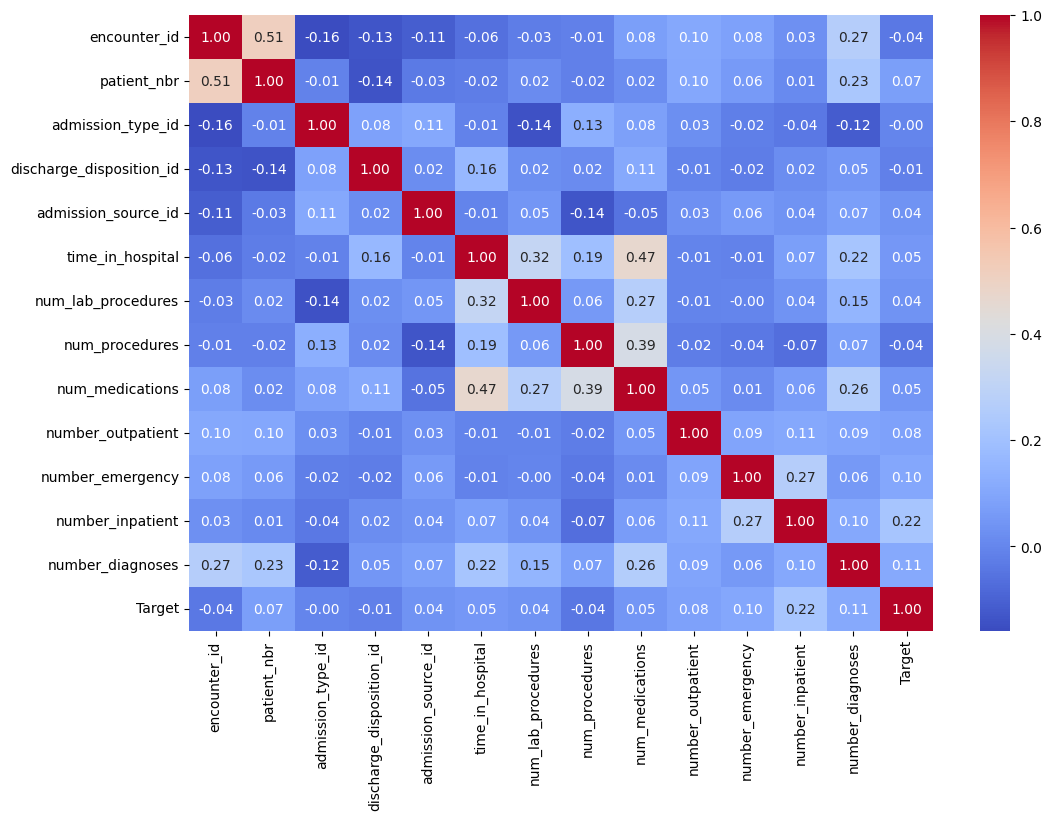

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(hospitalreadmission.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True ,fmt='.2f' )
plt.show()

In [23]:
hospitalreadmission.select_dtypes(include='number').corr()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,Target
encounter_id,1.000000,0.512028,-0.158961,-0.132876,-0.112402,-0.062221,-0.026062,-0.014225,0.076113,0.103756,0.082803,0.030962,0.265149,-0.038267
patient_nbr,0.512028,1.000000,-0.011128,-0.136814,-0.032568,-0.024092,0.015946,-0.015570,0.020665,0.103379,0.062352,0.012480,0.226847,0.074093
admission_type_id,-0.158961,-0.011128,1.000000,0.083483,0.106654,-0.012500,-0.143713,0.129888,0.079535,0.026511,-0.019116,-0.038161,-0.117126,-0.004923
discharge_disposition_id,-0.132876,-0.136814,0.083483,1.000000,0.018193,0.162748,0.023415,0.015921,0.108753,-0.008715,-0.024471,0.020787,0.046891,-0.014852
admission_source_id,-0.112402,-0.032568,0.106654,0.018193,1.000000,-0.006965,0.048885,-0.135400,-0.054533,0.027244,0.059892,0.036314,0.072114,0.039986
time_in_hospital,-0.062221,-0.024092,-0.012500,0.162748,-0.006965,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186,0.051289
num_lab_procedures,-0.026062,0.015946,-0.143713,0.023415,0.048885,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773,0.039253
num_procedures,-0.014225,-0.015570,0.129888,0.015921,-0.135400,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734,-0.044748
num_medications,0.076113,0.020665,0.079535,0.108753,-0.054533,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526,0.046772
number_outpatient,0.103756,0.103379,0.026511,-0.008715,0.027244,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152,0.082142


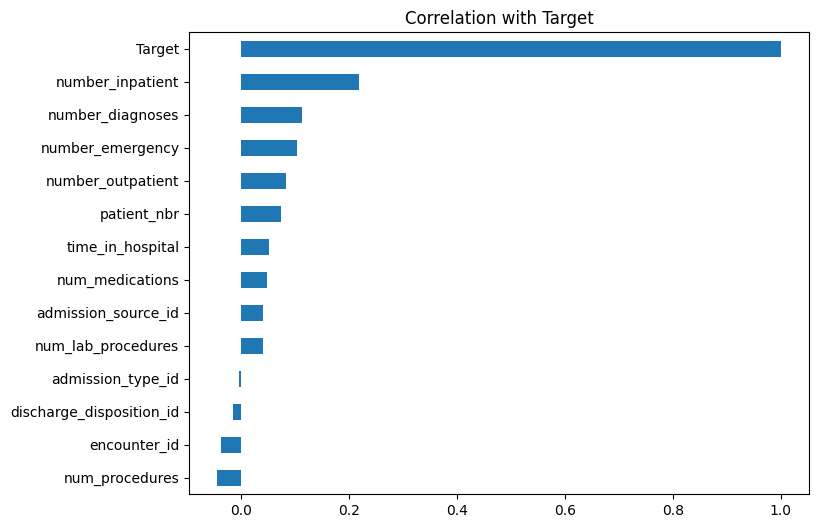

In [24]:
hospitalreadmission.select_dtypes(include='number').corr()['Target'].sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Correlation with Target")
plt.show()

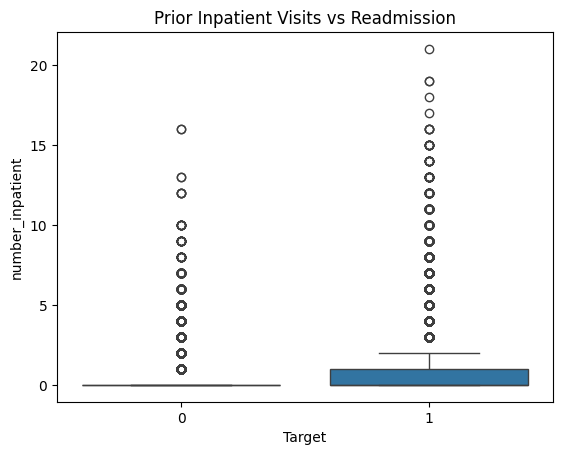

In [26]:
sns.boxplot(x='Target', y='number_inpatient', data=hospitalreadmission)
plt.title("Prior Inpatient Visits vs Readmission")
plt.show()

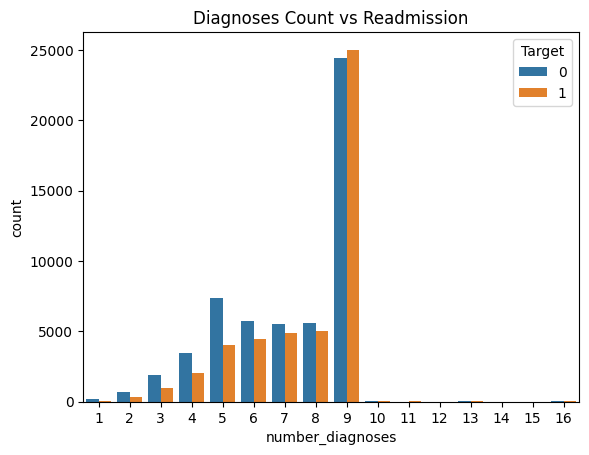

In [27]:
sns.countplot(hue='Target', x='number_diagnoses', data=hospitalreadmission)
plt.title("Diagnoses Count vs Readmission")
plt.show()

Step 5 - Data Preprocessing

In [28]:
hospitalreadmission.drop(['encounter_id','patient_nbr'], axis=1,inplace=True,errors='ignore')

In [30]:
from sklearn.preprocessing import LabelEncoder

df_encoded = hospitalreadmission.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

C:\Users\Tanishq\AppData\Local\Temp\ipykernel_17056\530742987.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


In [31]:
X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [33]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

top15 = feature_importance.sort_values(by='Importance', ascending=False).head(15)

print(top15)

                     Feature  Importance
10        num_lab_procedures    0.089231
16                    diag_1    0.085187
17                    diag_2    0.084372
18                    diag_3    0.082124
12           num_medications    0.077909
7           time_in_hospital    0.055249
15          number_inpatient    0.050117
2                        age    0.045918
5   discharge_disposition_id    0.041576
9          medical_specialty    0.040383
8                 payer_code    0.038608
19          number_diagnoses    0.038435
11            num_procedures    0.036184
37                   insulin    0.025050
4          admission_type_id    0.023883


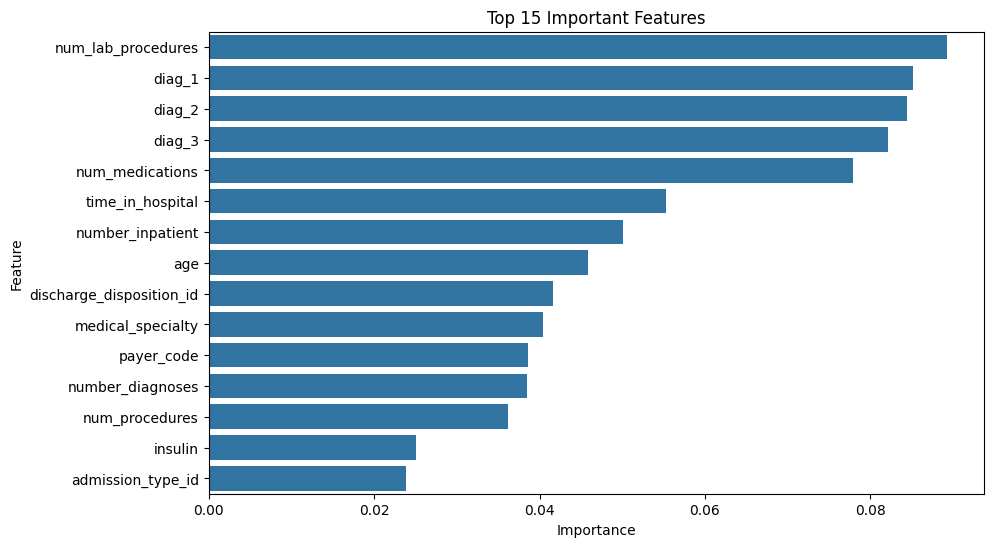

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top15)
plt.title("Top 15 Important Features")
plt.show()

In [35]:
best_features = ['num_lab_procedures','diag_1','diag_2','diag_3','num_medications','time_in_hospital','number_inpatient','age','discharge_disposition_id','number_diagnoses','num_procedures','insulin','admission_type_id','number_outpatient','number_emergency']

In [36]:
X = df_encoded[best_features]
y = df_encoded['Target']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step 6 - Model building

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.617569028200845
              precision    recall  f1-score   support

           0       0.61      0.81      0.70     10952
           1       0.64      0.39      0.49      9402

    accuracy                           0.62     20354
   macro avg       0.62      0.60      0.59     20354
weighted avg       0.62      0.62      0.60     20354



c:\Users\Tanishq\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6316203203301562
              precision    recall  f1-score   support

           0       0.64      0.73      0.68     10952
           1       0.62      0.52      0.57      9402

    accuracy                           0.63     20354
   macro avg       0.63      0.62      0.62     20354
weighted avg       0.63      0.63      0.63     20354



In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.6457207428515279
              precision    recall  f1-score   support

           0       0.65      0.75      0.69     10952
           1       0.64      0.53      0.58      9402

    accuracy                           0.65     20354
   macro avg       0.65      0.64      0.64     20354
weighted avg       0.65      0.65      0.64     20354



In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')

print(scores)
print(scores.mean())

[0.62813206 0.63096349 0.62069474 0.64599813 0.64486808]
0.6341313012129662


In [46]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

params = {
    'max_depth': [4,6],
    'n_estimators': [100,200],
    'learning_rate': [0.05,0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    params,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
0.6426202074739779


# Final Insights & What This Means

## What We Found

- Patients who had been admitted to the hospital multiple times in the past were more likely to come back again.  
- Older patients showed a higher chance of readmission, which suggests age-related health risks.  
- Patients taking many medicines often had more serious or complex health conditions.  
- Some patient groups had much lower risk, which can help hospitals focus attention where it is needed most.  

## What Hospitals Can Do

- Use this model as an early warning tool to identify high-risk patients before discharge.  
- Arrange follow-up calls or checkups after patients leave the hospital.  
- Give extra support for medicine management and treatment plans.  
- Provide more focused care for elderly patients and chronic disease cases.  
- Reduce avoidable readmissions, improve patient care, and lower costs.  

## Final Conclusion

This project shows how machine learning can help hospitals make smarter decisions. By identifying patients who may return soon, hospitals can take early action and improve both patient outcomes and operational efficiency.
